# E-Commerce Churn Prediction

## 1. Project Overview

- **Objective:** Predict customer churn to identify at-risk users for retention campaigns.
- **Business Context:** Reducing churn by 5% can increase profits by 25-95%. 
- **Target:** `is_churned` (0 = Retained, 1 = Churned)
- **Key Metric:** Maximize **Recall** (Sensitivity); We want to capture as many churners as possible, even if means raising a few false alarms (lower Precision)

## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, recall_score, f1_score, precision_score

import joblib

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

## 3. Data Loading

In [2]:
# Load dataset
df = pd.read_csv("../data/raw/churn_data.csv")

In [5]:
# Initial inspection
print("Shape:", df.shape)
df.head()

Shape: (30692, 8)


,user_id,days_since_last_order,total_orders,total_spend,avg_order_value,returned_orders,return_rate,is_churned
0,45874,15,9,342.120001,38.013333,0,0.000000,1
1,69396,130,9,634.590004,70.510000,4,0.444444,1
2,2057,187,9,594.919999,66.102222,0,0.000000,1
3,46395,102,10,397.910004,39.791000,0,0.000000,0
4,4966,213,10,773.589985,77.358998,6,0.600000,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30692 entries, 0 to 30691
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                30692 non-null  int64  
 1   days_since_last_order  30692 non-null  int64  
 2   total_orders           30692 non-null  int64  
 3   total_spend            30692 non-null  float64
 4   avg_order_value        30692 non-null  float64
 5   returned_orders        30692 non-null  int64  
 6   return_rate            30692 non-null  float64
 7   is_churned             30692 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 1.9 MB


In [7]:
df.describe(include="all").transpose()

,count,mean,std,min,25%,50%,75%,max
user_id,30692.0,50065.159586,28978.131947,1.00,24788.750000,50229.500000,75154.7500,100000.000000
days_since_last_order,30692.0,153.723446,104.830236,1.00,61.000000,140.000000,240.0000,364.000000
total_orders,30692.0,2.364395,1.636799,1.00,1.000000,2.000000,3.0000,13.000000
total_spend,30692.0,141.587503,143.050726,0.02,44.990000,96.495001,190.9525,1964.180002
avg_order_value,30692.0,59.829191,52.168838,0.02,30.169167,47.394167,72.0000,999.000000
returned_orders,30692.0,0.233286,0.650369,0.00,0.000000,0.000000,0.0000,7.000000
return_rate,30692.0,0.098135,0.261218,0.00,0.000000,0.000000,0.0000,1.000000
is_churned,30692.0,0.883944,0.320298,0.00,1.000000,1.000000,1.0000,1.000000


## 4. Data Cleaning & Preprocessing

In [8]:
# Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


In [9]:
# Check for missing values
print(df.isna().sum())

user_id                  0
days_since_last_order    0
total_orders             0
total_spend              0
avg_order_value          0
returned_orders          0
return_rate              0
is_churned               0
dtype: int64


## 5. Exploratory Data Analysis (EDA)

In [10]:
# Check target balance
churn_rate = df["is_churned"].mean()
print(f"Churn rate: {churn_rate:.2%} (1 = churned)")
df["is_churned"].value_counts()

Churn rate: 88.39% (1 = churned)


is_churned
1    27130
0     3562
Name: count, dtype: int64

**Insight**: 88.39% are churned, this suggests that we have a heavy imbalance.

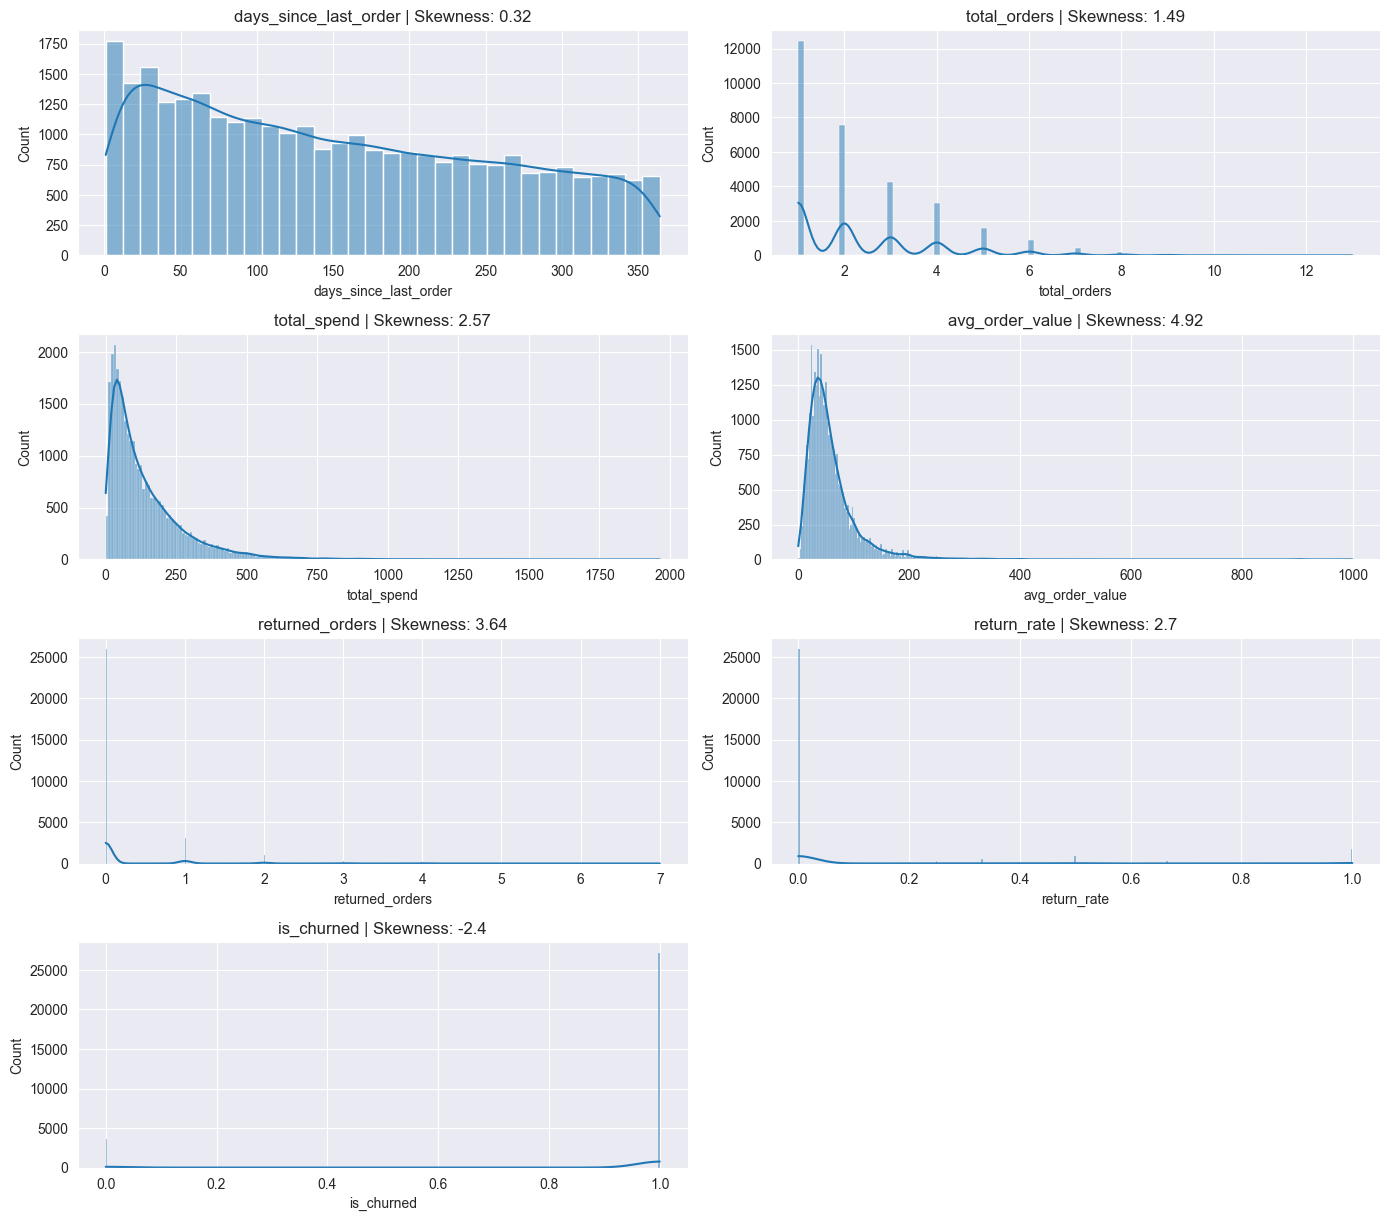

In [12]:
# Distribution of numerical features
numerical_features = (df.drop(columns='user_id')).select_dtypes(include=[np.number]).columns

plt.figure(figsize=(14, len(numerical_features) * 3))
for idx, feature in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

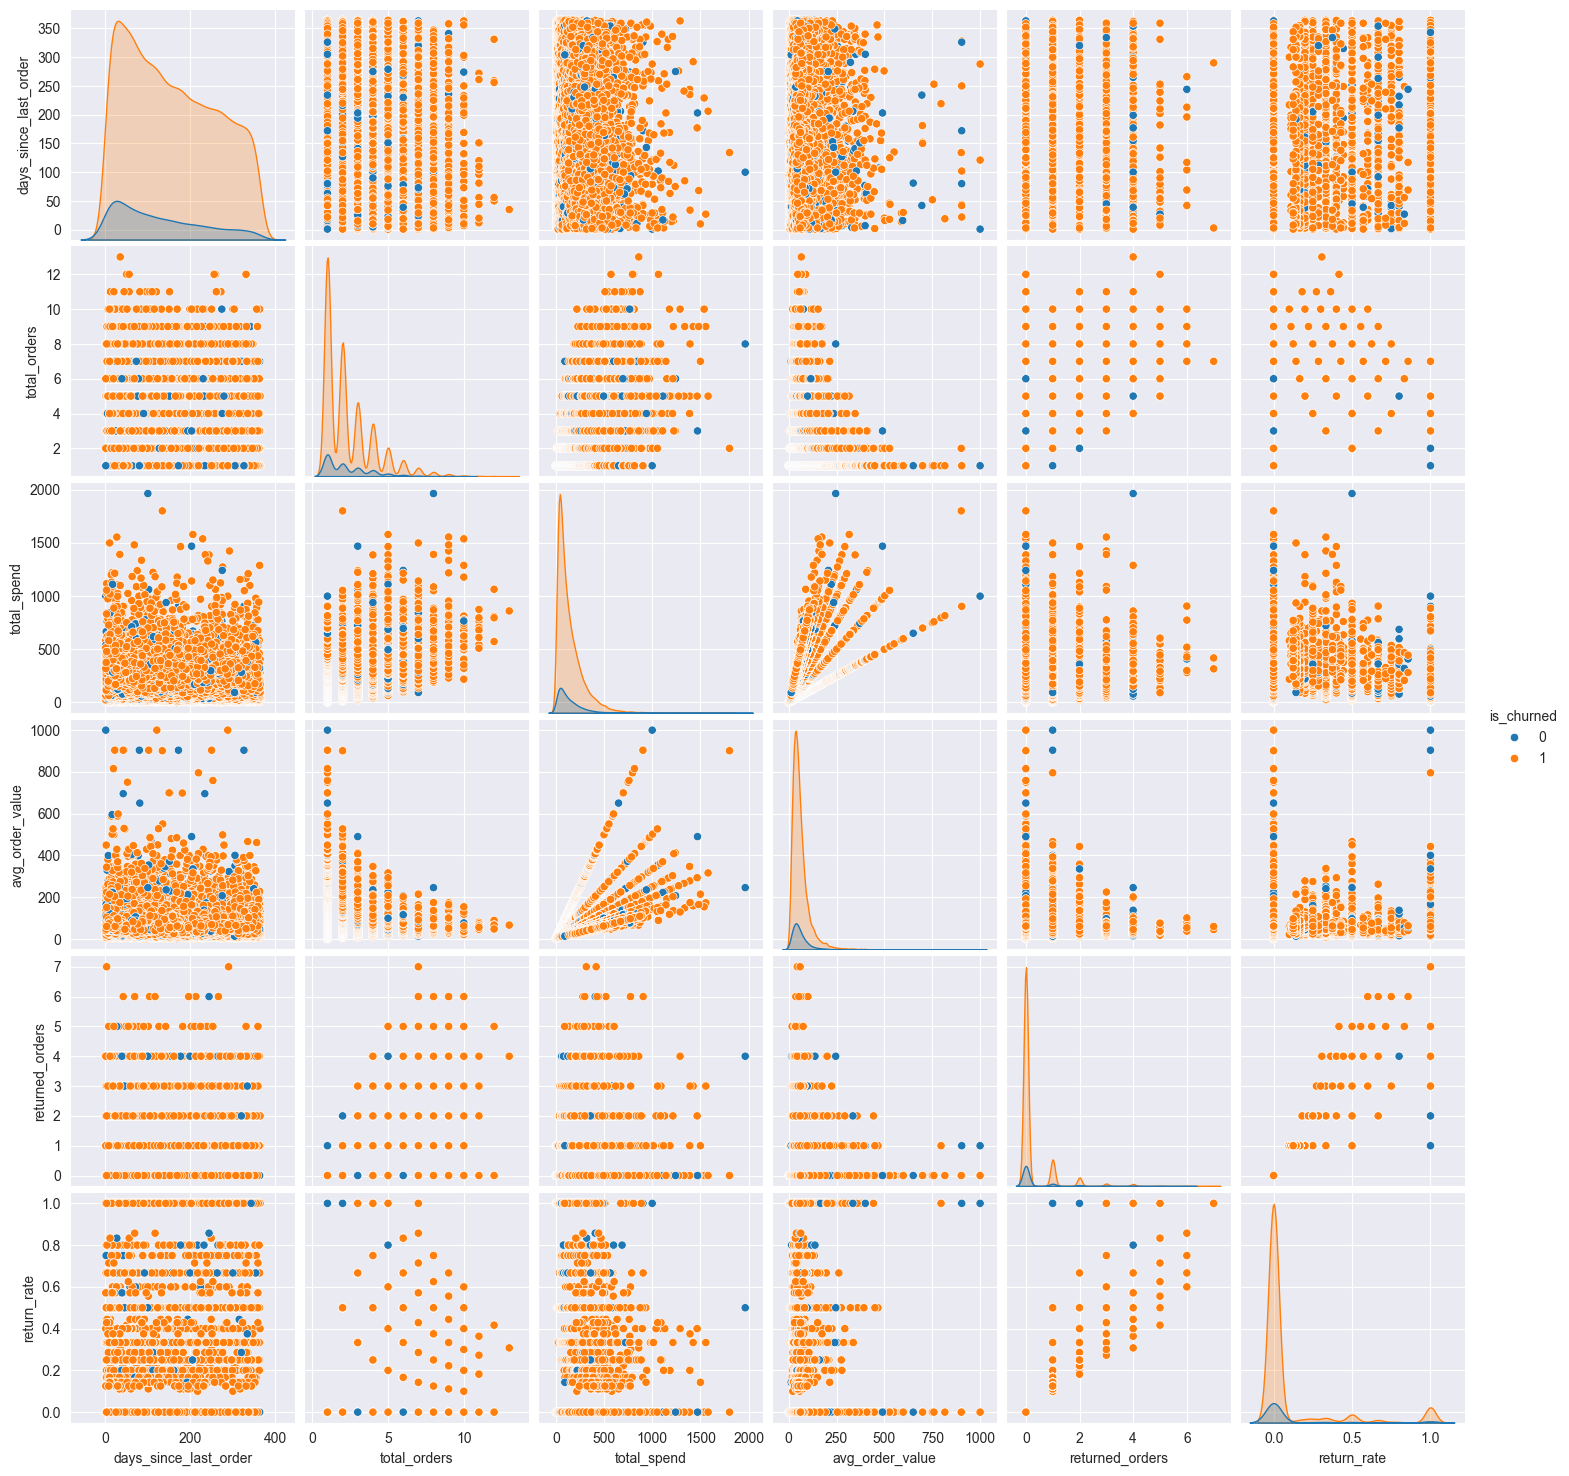

In [13]:
# Bivariate analysis
plt.figure(figsize=(10,6))
sns.pairplot(df.drop(columns='user_id'), hue='is_churned')

plt.show()

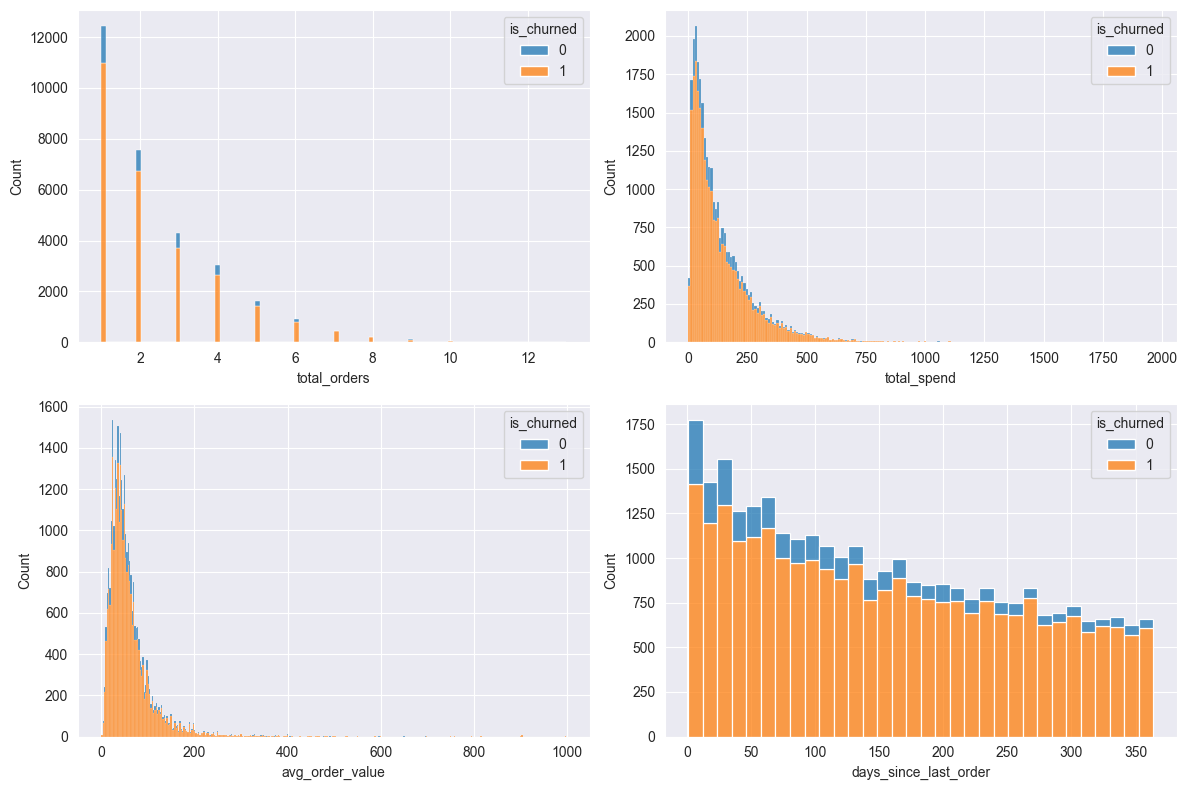

In [14]:
# Basic distribution plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=df, x="total_orders", hue="is_churned", multiple="stack", ax=axes[0,0])
sns.histplot(data=df, x="total_spend", hue="is_churned", multiple="stack", ax=axes[0,1])
sns.histplot(data=df, x="avg_order_value", hue="is_churned", multiple="stack", ax=axes[1,0])
sns.histplot(data=df, x="days_since_last_order", hue="is_churned", multiple="stack", ax=axes[1,1])
plt.tight_layout()
plt.show()

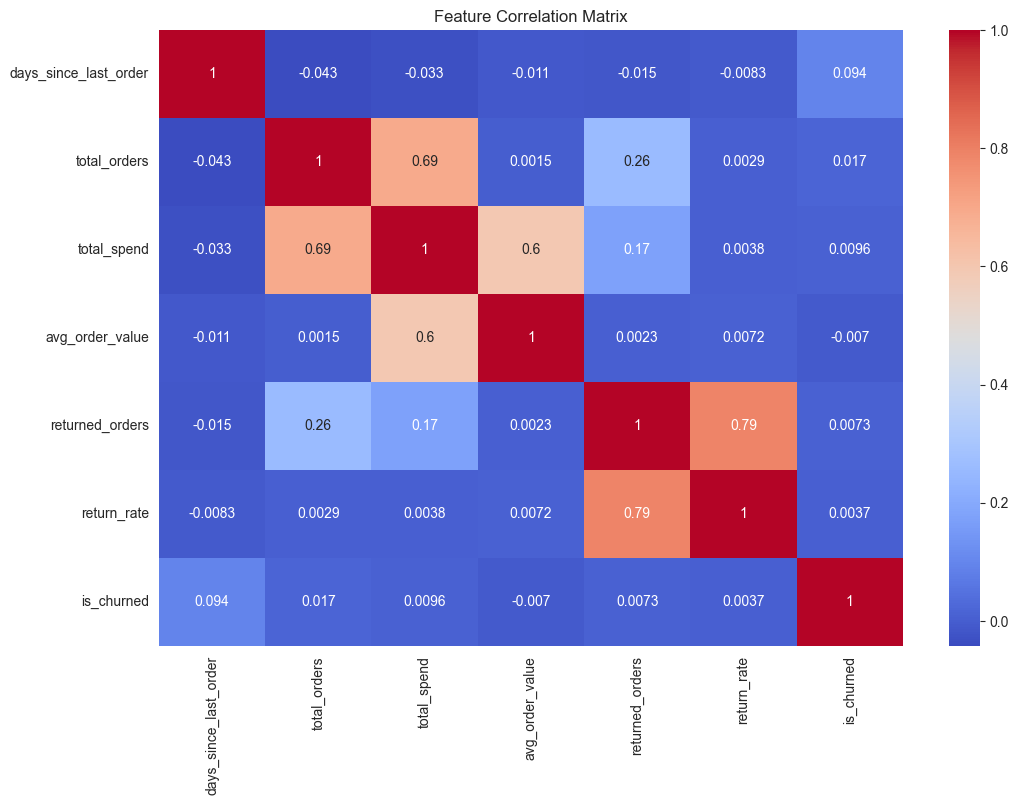

In [15]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=['user_id']).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

### 🔎 Insight 1: The "100-Day Turn"
**Hypothesis:** Recent users are more likely to stay, but when does the "drop-off" happen?

**Analysis:**
The density plot below separates users who eventually churned (Dark Blue, 1) vs. those who stayed (Light Teal, 0).
* **Observation:** The "Retained" distribution is tightly clustered between 0 and 60 days.
* **Critical Threshold:** Beyond **100 days**, the density of "Retained" users flatlines near zero.

> **💡 Business Recommendation:**
> Marketing intervention must happen **before Day 60**. Any "Win-Back" campaign triggered after Day 90 is likely wasting budget on users who have already permanently churned.

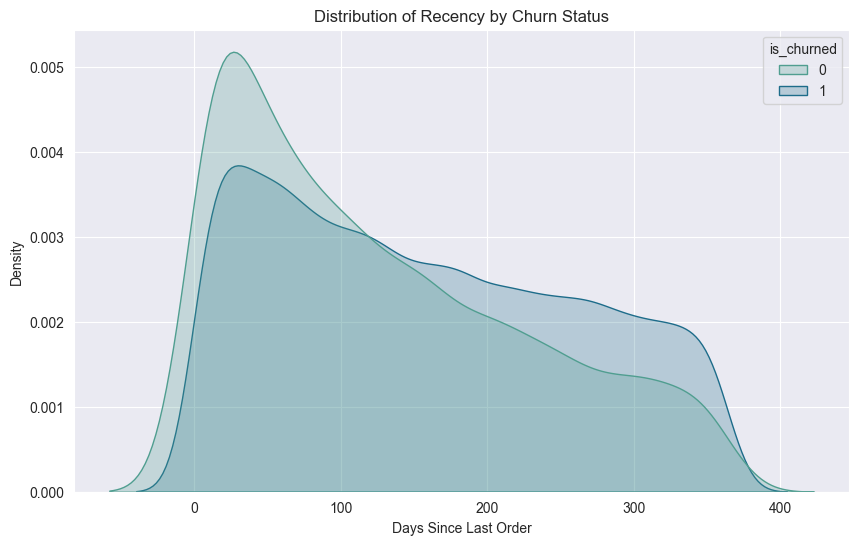

In [16]:
# Visualizing the separation between Churned (1) and Retained (0)
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, x='days_since_last_order', hue='is_churned', 
    fill=True, 
    common_norm=False,  # scale each distribution independently since the classes are imbalanced!
    palette='crest'
    )
plt.title("Distribution of Recency by Churn Status")
plt.xlabel("Days Since Last Order")
plt.show()

### 🔎 Insight 2: Does "Bad Experience" Drive Churn?
**Hypothesis:** Users who return items (indicating a bad product fit) are more likely to churn.

**Analysis:**
We binned users by their return rate (Items Returned / Total Orders) to see if high return correlate with high churn.
* **Observation:** The churn rate is consistently high across all group (>95%). Interestingly, users with **moderate returns (1-10%)** actually show the highest risk, while "Super Returners" (50%+) are statistically safer.

> **💡 Business Recommendation:**
> "Serial Returners" are not our highest churn risk. We should **avoid penalizing high-return behaviors** (e.g., removing free returns), as these users are just as likely to stay as zero-return customers. The friction of a return does not appear to drive attrition.

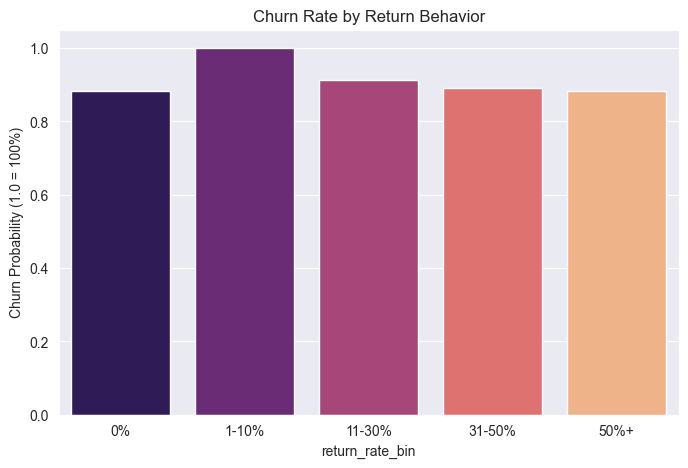

In [17]:
# Binning Return Rate to see trends
df['return_rate_bin'] = pd.cut(
    df['return_rate'], 
    bins=[-0.1, 0, 0.1, 0.3, 0.5, 1.0], 
    labels=["0%", "1-10%", "11-30%", "31-50%", "50%+"])

plt.figure(figsize=(8, 5))

# Look at the % of people who churned in each bin
sns.barplot(data=df, x='return_rate_bin', y='is_churned', errorbar=None, hue='return_rate_bin', palette='magma')
plt.title("Churn Rate by Return Behavior")
plt.ylabel("Churn Probability (1.0 = 100%)")
plt.show()

### 🔎 Insight 3: The "Whale" Trap: Does Spend Predict Loyalty?
**Hypothesis:** High-value customers ("Whales") are more loyal and less likely to churn than low-value buyers.

**Analysis:**
We compared the distribution of lifetime spend (`total_spend`) between Churned and Retained users to see if "VIPs" stick around longer.
* **Observation:** The distributions are nearly identical. The median spend for users who churned is indistinguishable from those who stayed. Being a "High Spender" provides **zero protection** against churning.

> **💡 Business Recommendation:**
> **Money doesn't buy loyalty.** We cannot rely on "VIP Status" (historical spend) to identify safe customers. A user who spent $500 last year is just as likely to leave as one who spent $50. Retention efforts should focus on **behavioral signals** (like Recency) rather than assuming high spenders are "safe."

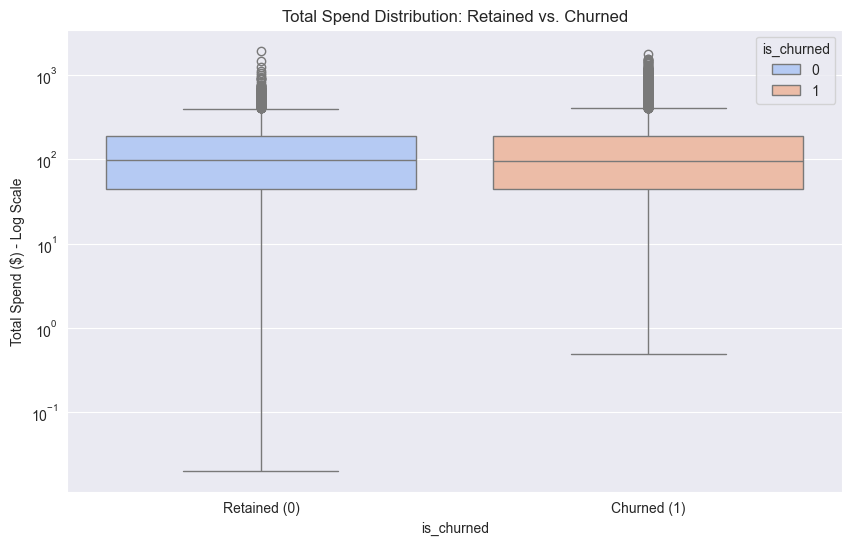

In [18]:
plt.figure(figsize=(10, 6))
# Log scale helps because spend is usually skewed
sns.boxplot(data=df, x='is_churned', y='total_spend', hue='is_churned', palette='coolwarm')
plt.yscale('log')
plt.title("Total Spend Distribution: Retained vs. Churned")
plt.ylabel("Total Spend ($) - Log Scale")
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])
plt.show()

## 6. Feature Engineering

In [ ]:
# Define target and features
y = df['is_churned']
X = df.drop(columns=['user_id', 'is_churned', 'return_rate_bin'])

## 7. Model Development

In [20]:
# Split data (stratified to keep the 5% retention rate in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
# Calculate scale weight for XGBoost
# Logic: sum(majority) / sum(minority)
scale_pos_weight = (y_train == 0).sum() / (y_train ==1).sum()
print(f"Computed scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

Computed scale_pos_weight for XGBoost: 0.13


In [22]:
%%time
# 1. Define models with class imbalance handling
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', 
        max_iter=1000,      # prevent convergence warnings
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', 
        n_estimators=100, 
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,  # handle class imbalance
        n_estimators=100,   # enough trees to converge without excessive computation
        max_depth=4,        # shallow trees to prevent overfitting
        learning_rate=0.1,  # standard for initial comparison
        random_state=42,
        eval_metric='logloss'
    )
}

# 2. Iterate & Evaluate
results = []

for name, model in models.items():
    # Use scaled data for Logistic Regression, normal for Trees
    if name == 'Logistic Regression':
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })

# 3. Create Comparison DataFrame
results_df = pd.DataFrame(results)

# 4. Select the best model based based on Recall
display(results_df.sort_values(by='Recall', ascending=False).style.background_gradient(cmap='Blues'))

,Model,Accuracy,Recall,Precision,F1 Score,AUC-ROC
1,Random Forest,0.860889,0.969412,0.884350,0.924930,0.517977
2,XGBoost,0.567193,0.578220,0.895037,0.702564,0.547297
0,Logistic Regression,0.518163,0.512438,0.899127,0.652817,0.551388


CPU times: user 1.9 s, sys: 535 ms, total: 2.44 s
Wall time: 1.94 s


## 8. Model Evaluation

In [23]:
# Determine the best model based on the highest Recall
best_model = models['Random Forest']

In [24]:
# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [25]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.13      0.03      0.05       712
           1       0.88      0.97      0.92      5427

    accuracy                           0.86      6139
   macro avg       0.51      0.50      0.49      6139
weighted avg       0.80      0.86      0.82      6139



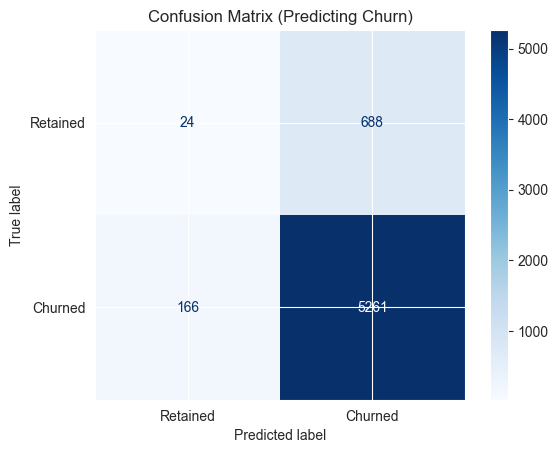

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Predicting Churn)")
plt.show()

In [27]:
# Save the model (for the App later)
joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

## 9. Insights

### 🔎 Insight 1: Feature Importance


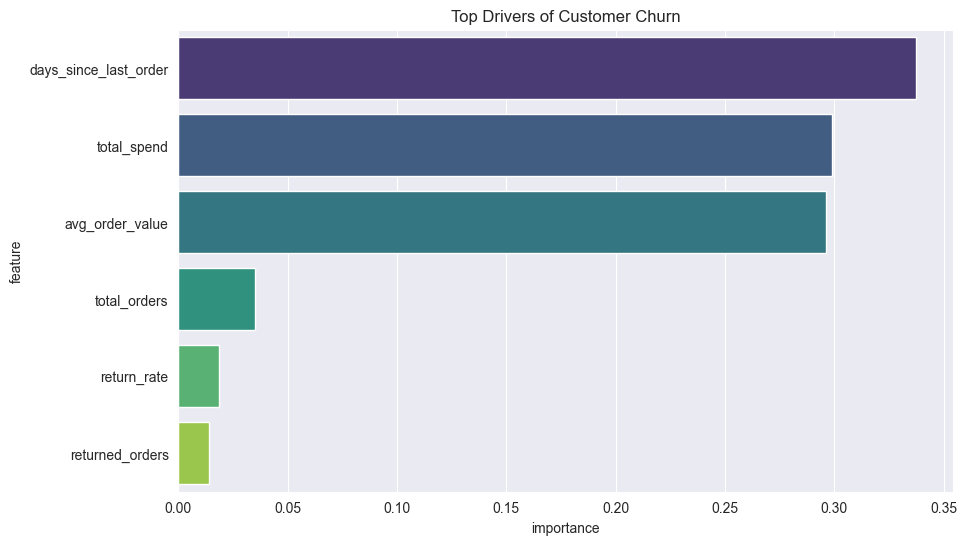

In [28]:
# Feature Importances
# --> "What drives customer churn?"
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', hue='feature', palette='viridis')
plt.title("Top Drivers of Customer Churn")
plt.show()

### 🔎 Insight 2: Profit Simulation


In [29]:
y_test

697      1
27226    1
5221     1
26433    1
24996    1
        ..
11063    1
24964    1
18930    1
29274    1
25803    1
Name: is_churned, Length: 6139, dtype: int64

In [30]:
y_test.values

array([1, 1, 1, ..., 1, 1, 1], shape=(6139,))

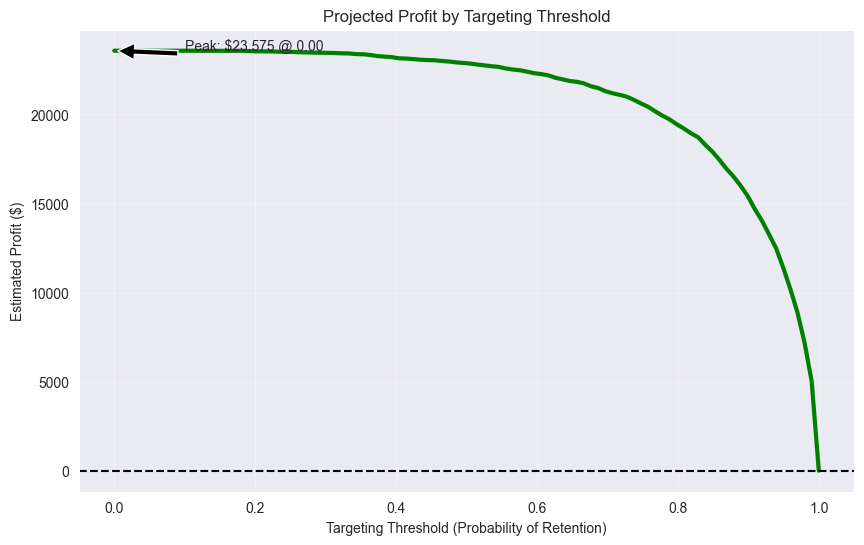

Optimal Strategy: Target customers with < 0% retention probability for maximum profit of $23575.00


In [31]:
# Scenario: 
# - We offer a $5 discount to users we think will churn (Target = 1).
# - If we save them, we gain $50 in CLV (Customer Lifetime Value).
# - Success rate: 20%
# - We want to find the optimal targeting threshold to maximize profit.

results = pd.DataFrame({
    'actual_churned': y_test.values,
    'churn_prob': y_prob # Probability of Churn
})

# We target users with low retention probability (High churn risk)
# Let's test different thresholds: "Target everyone below 20% probability", "Below 30%", etc.
thresholds = np.linspace(0, 1, 100)
profits = []

for t in thresholds:
    # Who do we target? (Anyone with probability > t)
    targets = results[results['churn_prob'] > t]
    
    # Costs & gains
    n_campaigns = len(targets)
    cost = n_campaigns * 5 # $5 per coupon
    
    # Assume the campaign saves 20% of the churners we target
    # Real churners in our target list:
    real_churners_targeted = targets[targets['actual_churned'] == 1]
    saved_customers = len(real_churners_targeted) * 0.2
    
    revenue = saved_customers * 50 # $50 CLV gained per saved customer
    
    profit = revenue - cost
    profits.append(profit)
    

# Plot the Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, color='green', linewidth=3)
plt.axhline(0, color='black', linestyle='--')
plt.title("Projected Profit by Targeting Threshold")
plt.xlabel("Targeting Threshold (Probability of Retention)")
plt.ylabel("Estimated Profit ($)")

# Find peak profit point
max_profit = max(profits)
optimal_threshold = thresholds[np.argmax(profits)]

plt.annotate(f'Peak: ${max_profit:,.0f} @ {optimal_threshold:.2f}', 
             xy=(optimal_threshold, max_profit), 
             xytext=(optimal_threshold+0.1, max_profit),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Strategy: Target customers with < {optimal_threshold:.0%} retention probability for maximum profit of ${max_profit:.2f}")

## 10. Conclusion & Next Steps

### Key Findings:

- `days_since_last_order`, `total_orders`, and `avg_order_value` are the top predictors of churn.


### Recommendations:

- Target users with `days_since_last_order` < 